In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import spiceypy as spice

In [4]:
# SPICE test
spice.tkvrsn('TOOLKIT')

'CSPICE_N0067'

Import SPICE user Lib

In [5]:
import sys

# import SPICE user lib
sys.path.append('../lib/')
import cassini_spice_lib as cas_lib
import my_spice_lib as my_lib

Load SPICE kernels

In [6]:
# load SPICE ketnels
cas_lib.spice_ini()

S/C orbit around Saturn

In [7]:
# set date/time
utctim = '2004-06-01T00:00:30'    # start date/time
et_ex = spice.str2et(utctim)      # seconds
dt = 60*60*24   # time step [second]
nd = 365*13     # number of data
et = et_ex + dt * np.arange(0, nd)

# calculate target position with spice
x, y, z, r, lat, lon = my_lib.get_pos_xref(
    et, ref='IAU_SATURN', tar='CASSINI', org='SATURN', x_ref='SUN', corr='LT+S')


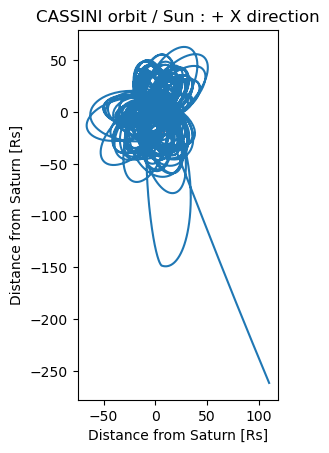

In [8]:
fig,ax = plt.subplots()

# plot spacecraft orbit
rs_km = 58232.0  # Saturn radii [km] 
plt.plot(x/rs_km, y/rs_km)

# plot moon orbits (Titan)
c_t = patches.Circle( xy=(0,0), radius=1221865.0/rs_km, edgecolor='red', facecolor='none', linewidth=0.5)
ax.add_patch(c_t)

plt.title('CASSINI orbit / Sun : + X direction')
plt.xlabel('Distance from Saturn [Rs]')
plt.ylabel('Distance from Saturn [Rs]')
ax.set_aspect('equal')
plt.show()


S/C orbit around Titan

See also (CASSINI Titan flyby)
https://atmos.nmsu.edu/data_and_services/atmospheres_data/Cassini/sci-titan-flybys.html


In [9]:
# set date/time
#utctim = '2004-06-01T00:00:30'    # start date/time
#dt = 60*60          # time step [second]
#nd = 24*365*13      # number of data
utctim = '2004-10-01T00:00:30'    # start date/time
dt = 60*60          # time step [second]
nd = 24*90      # number of data
et_ex = spice.str2et(utctim)        # seconds
et = et_ex + dt * np.arange(0, nd)

# calculate target position with spice
#x, y, z, r, lat, lon = my_lib.get_pos(
#    et, ref='IAU_SATURN', tar='CASSINI', org='TITAN')
x, y, z, r, lat, lon = my_lib.get_pos_xref(
    et, ref='IAU_SATURN', tar='CASSINI', org='TITAN', x_ref='SATURN', corr='LT+S')



(-1.0, 40.0)

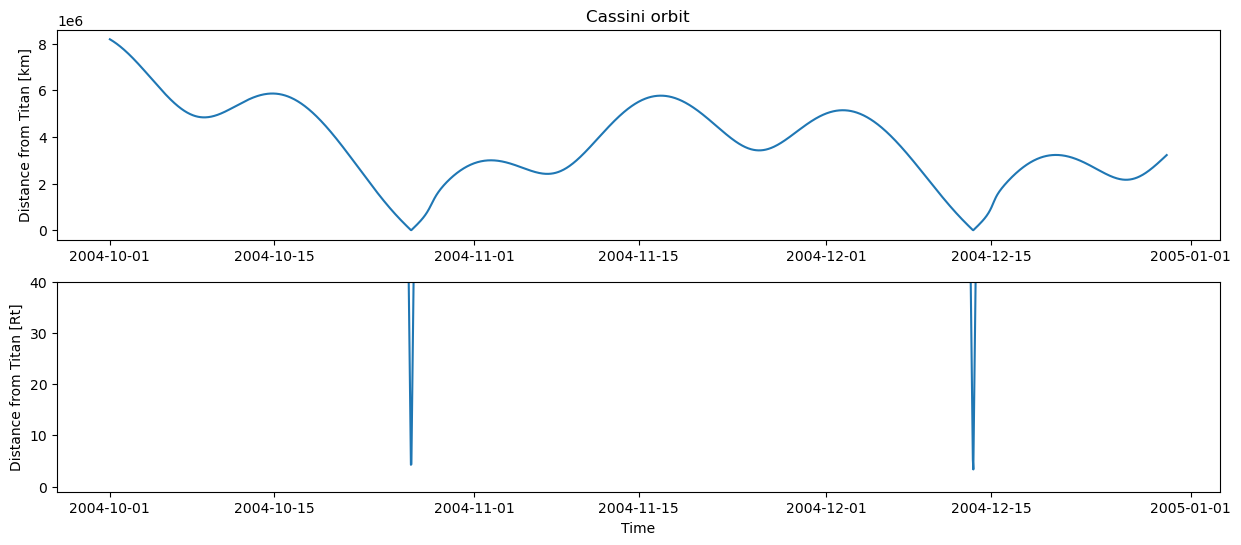

In [10]:
# plot
titan_km = 2574.7
td = spice.et2datetime(et)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15.0, 6.0))

ax1.plot(td, r)
ax1.set_title('Cassini orbit')
ax1.set_ylabel('Distance from Titan [km]')

ax2.plot(td, r/titan_km)
ax2.set_xlabel('Time')
ax2.set_ylabel('Distance from Titan [Rt]')
ax2.set_ylim([-1.0,40.0])


In [19]:
# set date/time
utctim = '2004-10-20T00:00:30'    # start date/time
dt = 60            # time step [second]
nd = 60*24*10      # number of data
et_ex = spice.str2et(utctim)        # seconds
et = et_ex + dt * np.arange(0, nd)

# calculate target position with spice
x, y, z, r, lat, lon = my_lib.get_pos_xref(
    et, ref='IAU_SATURN', tar='CASSINI', org='TITAN', x_ref='SATURN', corr='LT+S')

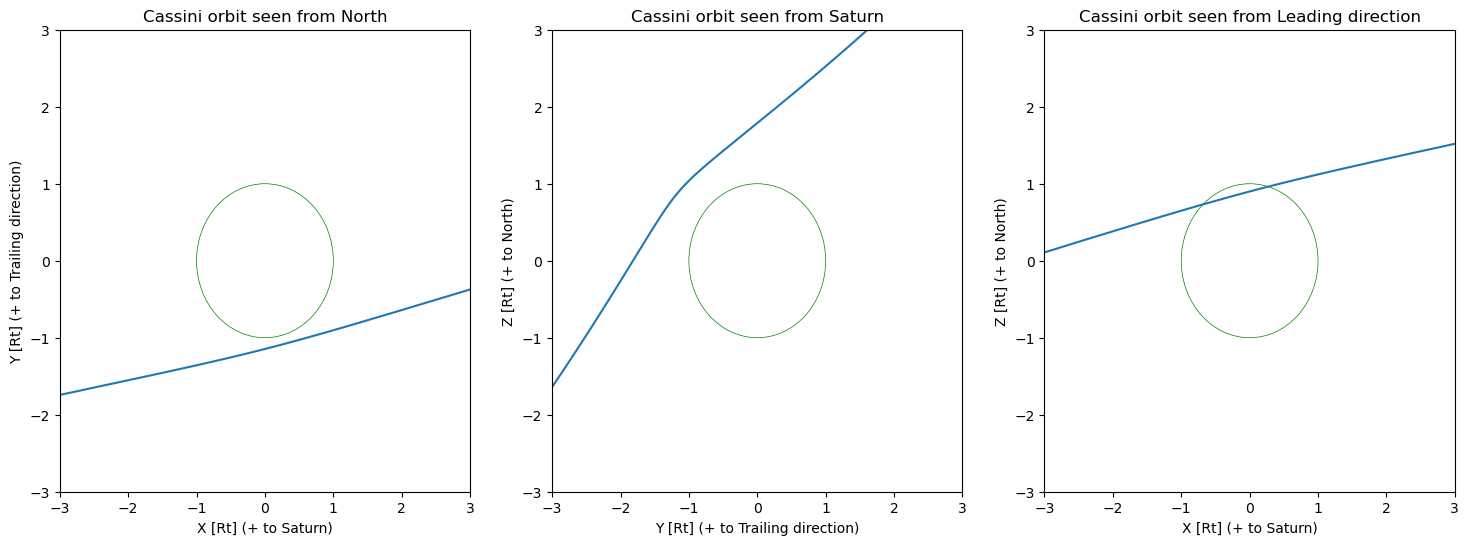

In [26]:
#plot
ascale = 3.0

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(18.0, 6.0))

ax1.plot(x/titan_km, y/titan_km)
ax1.set_title('Cassini orbit seen from North')
ax1.set_xlabel('X [Rt] (+ to Saturn)')
ax1.set_ylabel('Y [Rt] (+ to Trailing direction)')
ax1.set_xlim([-ascale,ascale])
ax1.set_ylim([-ascale,ascale])
ct = patches.Circle( xy=(0,0), radius=1.0, edgecolor='green', facecolor='none', linewidth=0.5)
ax1.add_patch(ct)

ax2.plot(y/titan_km, z/titan_km)
ax2.set_title('Cassini orbit seen from Saturn')
ax2.set_xlabel('Y [Rt] (+ to Trailing direction)')
ax2.set_ylabel('Z [Rt] (+ to North)')
ax2.set_xlim([-ascale,ascale])
ax2.set_ylim([-ascale,ascale])
ct = patches.Circle( xy=(0,0), radius=1.0, edgecolor='green', facecolor='none', linewidth=0.5)
ax2.add_patch(ct)

ax3.plot(x/titan_km, z/titan_km)
ax3.set_title('Cassini orbit seen from Leading direction')
ax3.set_xlabel('X [Rt] (+ to Saturn)')
ax3.set_ylabel('Z [Rt] (+ to North)')
ax3.set_xlim([-ascale,ascale])
ax3.set_ylim([-ascale,ascale])
ct = patches.Circle( xy=(0,0), radius=1.0, edgecolor='green', facecolor='none', linewidth=0.5)
ax3.add_patch(ct)
